In [1]:
# Cell 1: imports, paths, constants, and style

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "grw_global", "ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "grw_global": "GRW-G", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "ar1_s_globalinit": "AR(1)-GRW-S-G", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "grw_global": "#8C564B", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "ar1_s_globalinit": "#17BECF", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]


def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate

def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)


def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [2]:
emp = pd.read_csv(PREPARE / "df_traj_all.csv")
emp["CareerAge"] = emp["CareerAgeZero"].astype(int)
emp = emp.sort_values(["dblp_id", "CareerAge"]).copy()
grouped = emp.groupby("dblp_id", sort=False)
emp["pubs_adj_next_model"] = grouped["pubs_adj"].shift(-1)
emp["CareerAge_next_model"] = grouped["CareerAge"].shift(-1)
emp["log_pubs_adj"] = np.log(emp["pubs_adj"] + EPS)
emp["log_pubs_next"] = grouped["log_pubs_adj"].shift(-1)
emp["q_adj_delta"] = emp["pubs_adj_next_model"] - emp["pubs_adj"]
emp["log_delta"] = emp["log_pubs_next"] - emp["log_pubs_adj"]
emp["state"] = emp["pubs_adj"].gt(0).astype(int)
emp["next_state"] = emp["pubs_adj_next_model"].gt(0).astype(int)
is_next_year = emp["CareerAge_next_model"].eq(emp["CareerAge"] + 1)
emp_fit = emp.loc[is_next_year & emp["CareerAge"].between(0, Y - 1)].copy()

full_group = emp.groupby("dblp_id")["CareerAge"]
full_mask = full_group.transform("size").eq(Y + 1) & full_group.transform("min").eq(0) & full_group.transform("max").eq(Y)
emp_full_frame = emp.loc[full_mask].copy()
emp_panel_df = emp_full_frame.pivot(index="CareerAge", columns="dblp_id", values="pubs_adj").reindex(np.arange(Y + 1))
emp_panel = emp_panel_df.to_numpy(dtype=float)

simulation_registry = pd.read_csv(SIMULATE / "simulation-registry.csv")
available_models = [tag for tag in MODEL_ORDER if (SIMULATE / tag / "trajectories.npy").is_file()]
trajs = {tag: np.load(SIMULATE / tag / "trajectories.npy", mmap_mode="r", allow_pickle=False) for tag in available_models}

In [3]:
LAPLACE_WINDOWS = [("Pooled", 0, 19), ("Year 0", 0, 0), ("Years 1-4", 1, 4), ("Years 5-7", 5, 7), ("Years 8-20", 8, 19)]

def clean_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]

def laplace_details(values):
    values = clean_values(values)
    mu = np.median(values)
    alpha = np.mean(np.abs(values - mu))
    if len(values) < 3 or not np.isfinite(alpha) or alpha <= 0:
        return {"mu": mu, "alpha": alpha, "ks": np.nan, "corr": np.nan, "n": len(values)}
    (_, _), (_, _, corr) = stats.probplot((values - mu) / alpha, dist="laplace", fit=True, rvalue=True)
    ks = stats.kstest(values, "laplace", args=(mu, alpha)).statistic
    return {"mu": mu, "alpha": alpha, "ks": ks, "corr": float(corr), "n": len(values)}

def empirical_delta(start, end):
    return emp_fit.loc[emp_fit["CareerAge"].between(start, end), "q_adj_delta"].to_numpy(dtype=float)

def simulated_delta(values, start, end):
    return np.asarray(values[1:] - values[:-1])[start:end + 1].ravel()

rows = []
for window, start, end in LAPLACE_WINDOWS:
    rows.append({"source": "Empirical", "source_type": "empirical", "model_tag": "empirical", "window": window, "transition_year_start": start, "transition_year_end": end, **laplace_details(empirical_delta(start, end))})
    for tag in available_models:
        rows.append({"source": MODEL_NAMES[tag], "source_type": "simulated", "model_tag": tag, "window": window, "transition_year_start": start, "transition_year_end": end, **laplace_details(simulated_delta(trajs[tag], start, end))})
laplace_summary = pd.DataFrame(rows)
laplace_summary.to_csv(RESULTS / "laplace-fit-summary.csv", index=False)
display(laplace_summary)

,source,source_type,model_tag,window,transition_year_start,transition_year_end,mu,alpha,ks,corr,n
0,Empirical,empirical,empirical,Pooled,0,19,-0.072124,3.548548,0.062832,0.998850,27033
1,ARW4,simulated,arw4,Pooled,0,19,-0.323343,3.549747,0.025206,0.991309,200000
2,Unfitted-GRW,simulated,unfitted_grw,Pooled,0,19,-0.000373,7.587179,0.222379,0.289124,200000
3,GRW-Y,simulated,grw_y,Pooled,0,19,0.000000,1902.723361,0.423618,0.100576,200000
4,GRW-G,simulated,grw_global,Pooled,0,19,0.000000,1836.381669,0.428657,0.141214,200000
5,AR(1)-GRW-Y,simulated,ar1_y,Pooled,0,19,0.000000,5.821009,0.067314,0.888171,200000
6,AR(1)-GRW-S,simulated,ar1_s,Pooled,0,19,0.000000,5.901310,0.068694,0.895002,200000
7,AR(1)-GRW-S-G,simulated,ar1_s_globalinit,Pooled,0,19,0.010845,5.891469,0.068570,0.892659,200000
8,Hurdle-AR(1)-GRW-S,simulated,hurdle_ar1_s,Pooled,0,19,0.060639,4.038985,0.052334,0.971241,200000
9,Hurdle-AR(1)-GRW-S-P,simulated,hurdle_ar1_s_p,Pooled,0,19,0.000000,4.031552,0.033214,0.967808,200000


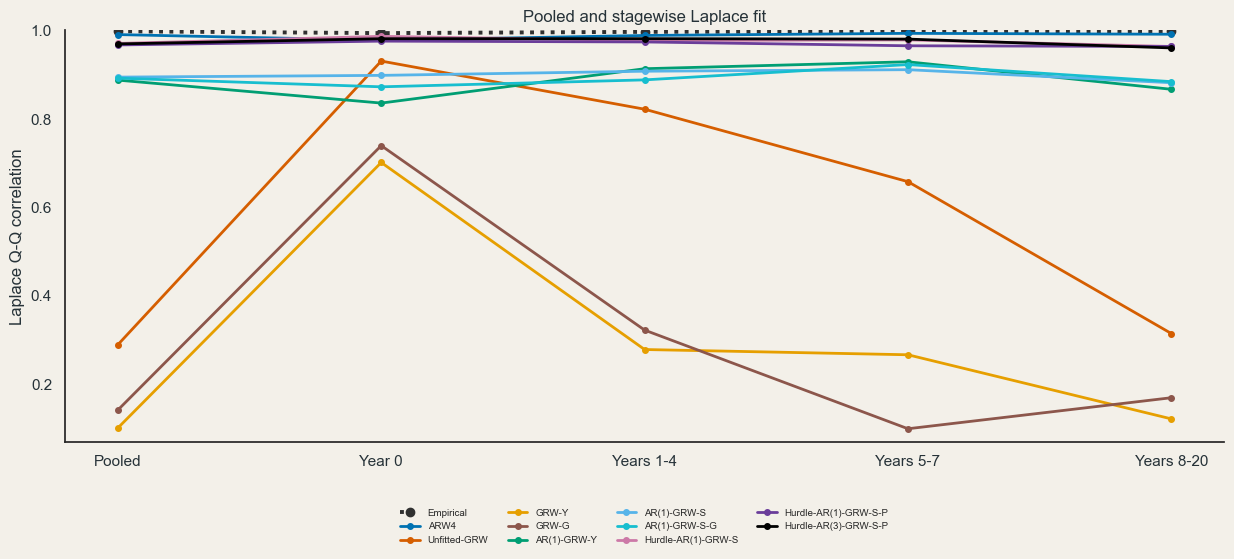

In [4]:
# Cell 4: all-model pooled and stagewise Laplace Q-Q correlations

fig, ax = plt.subplots(figsize=(12.5, 5.8))
fig.patch.set_facecolor(PAPER_BG)
style_axis(ax)
order = [window for window, _, _ in LAPLACE_WINDOWS]
x = np.arange(len(order))
emp_corr = laplace_summary.loc[laplace_summary["source_type"].eq("empirical")].set_index("window").reindex(order)["corr"]
ax.plot(x, emp_corr, color=EMP_COLOR, lw=2.8, marker="o", ms=6, ls=":", label="Empirical")
for tag in available_models:
    values = laplace_summary.loc[laplace_summary["model_tag"].eq(tag)].set_index("window").reindex(order)["corr"]
    ax.plot(x, values, color=MODEL_COLORS[tag], lw=2, marker="o", ms=4, label=MODEL_NAMES[tag])
ax.set_xticks(x, order)
ax.set_ylabel("Laplace Q-Q correlation")
ax.set_ylim(max(0, laplace_summary["corr"].min() - 0.03), 1.001)
ax.set_title("Pooled and stagewise Laplace fit")
ax.legend(frameon=False, ncol=4, fontsize=7, bbox_to_anchor=(0.5, -0.14), loc="upper center")
fig.tight_layout()
savefig(fig, "laplace_correlation_all_models.png")
plt.show()

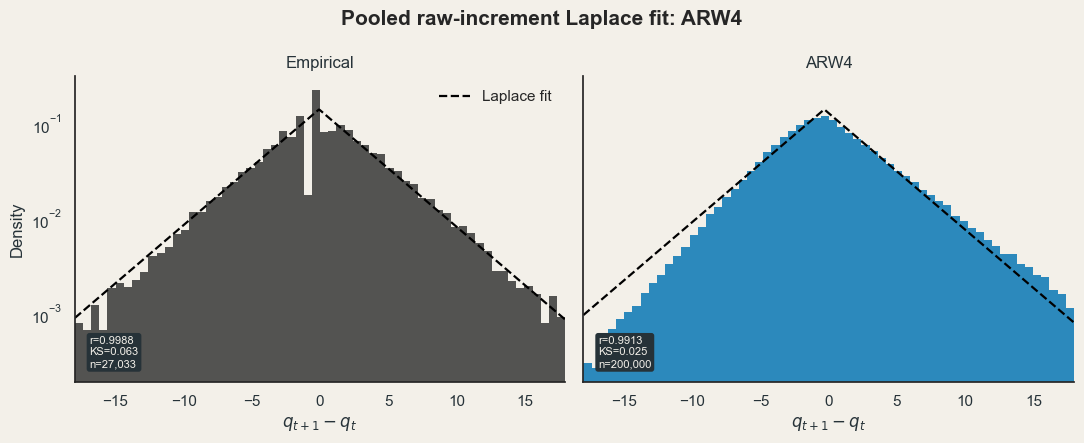

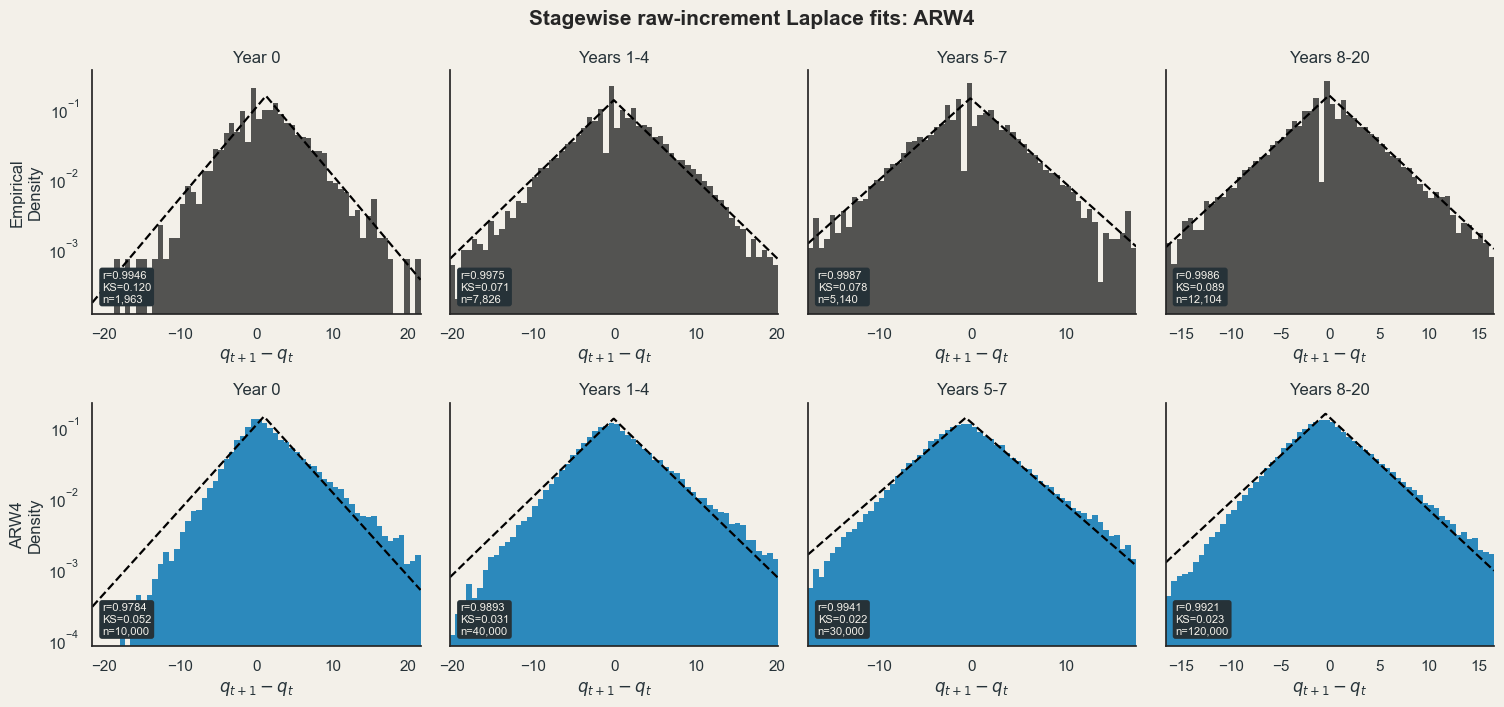

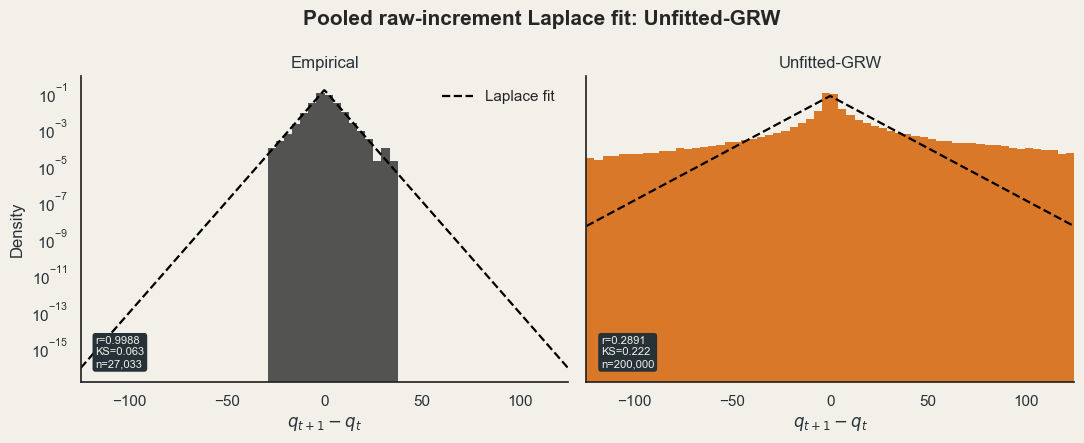

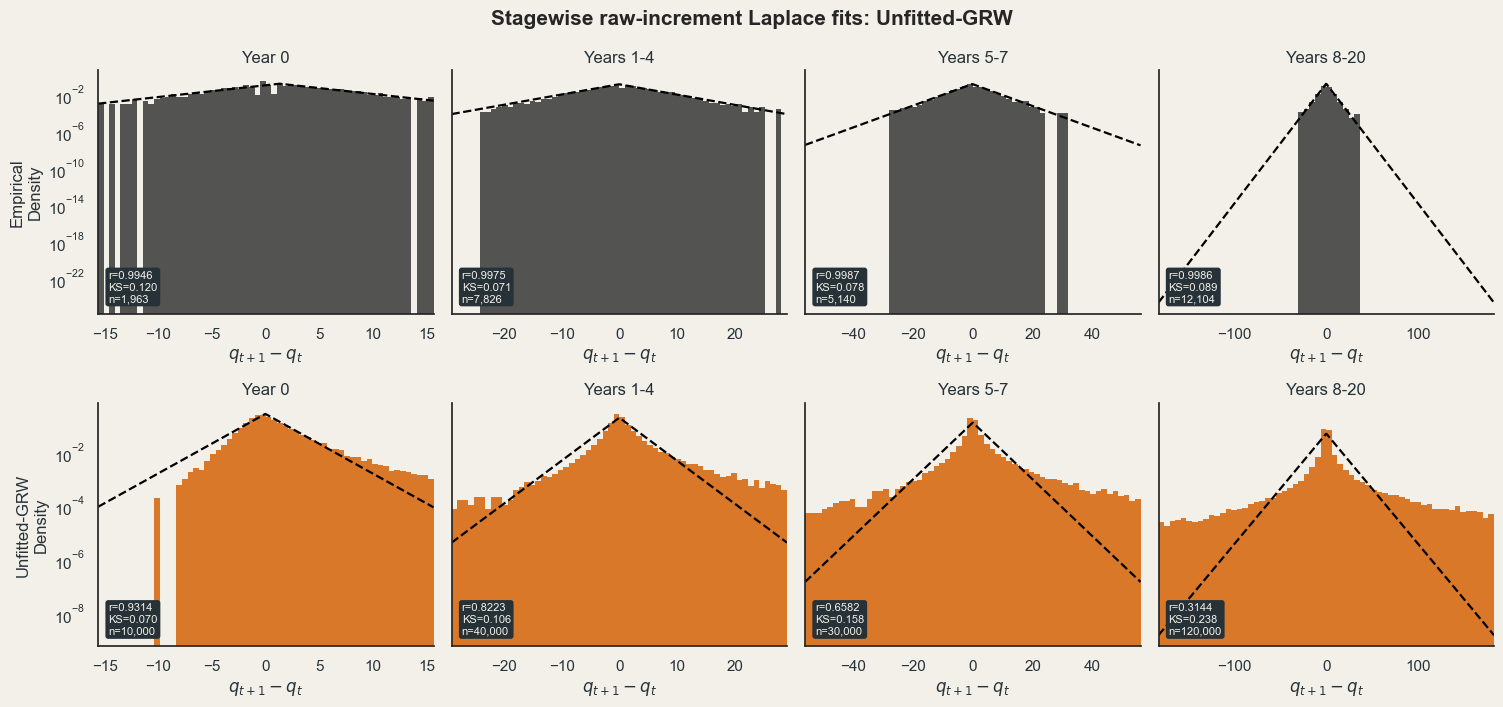

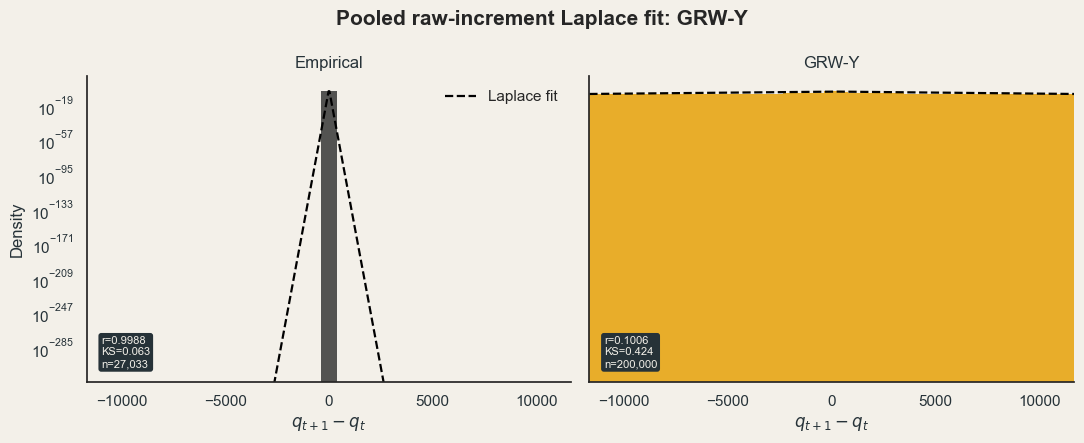

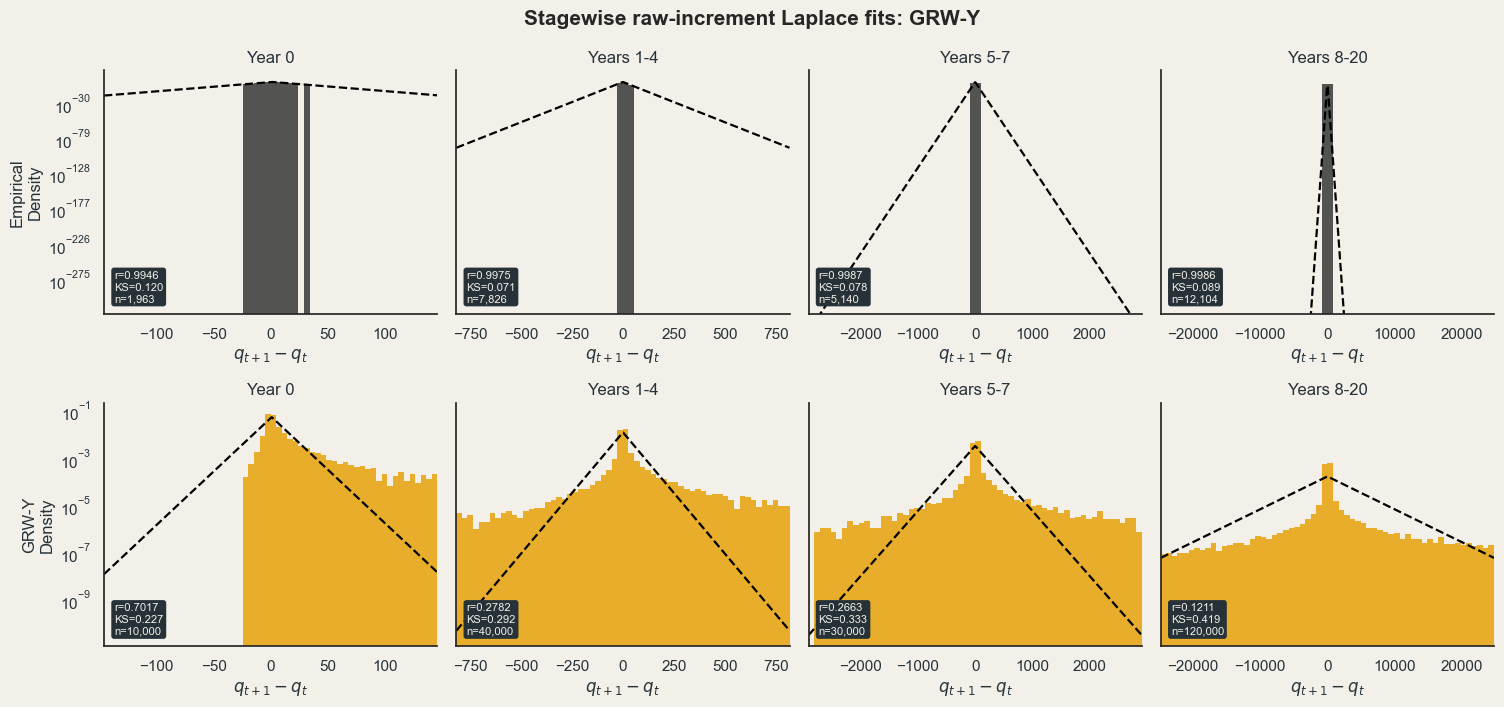

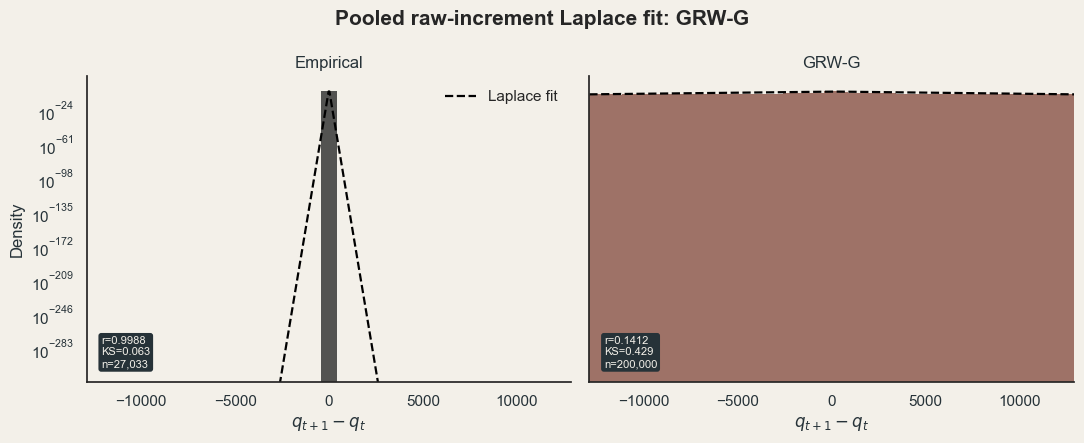

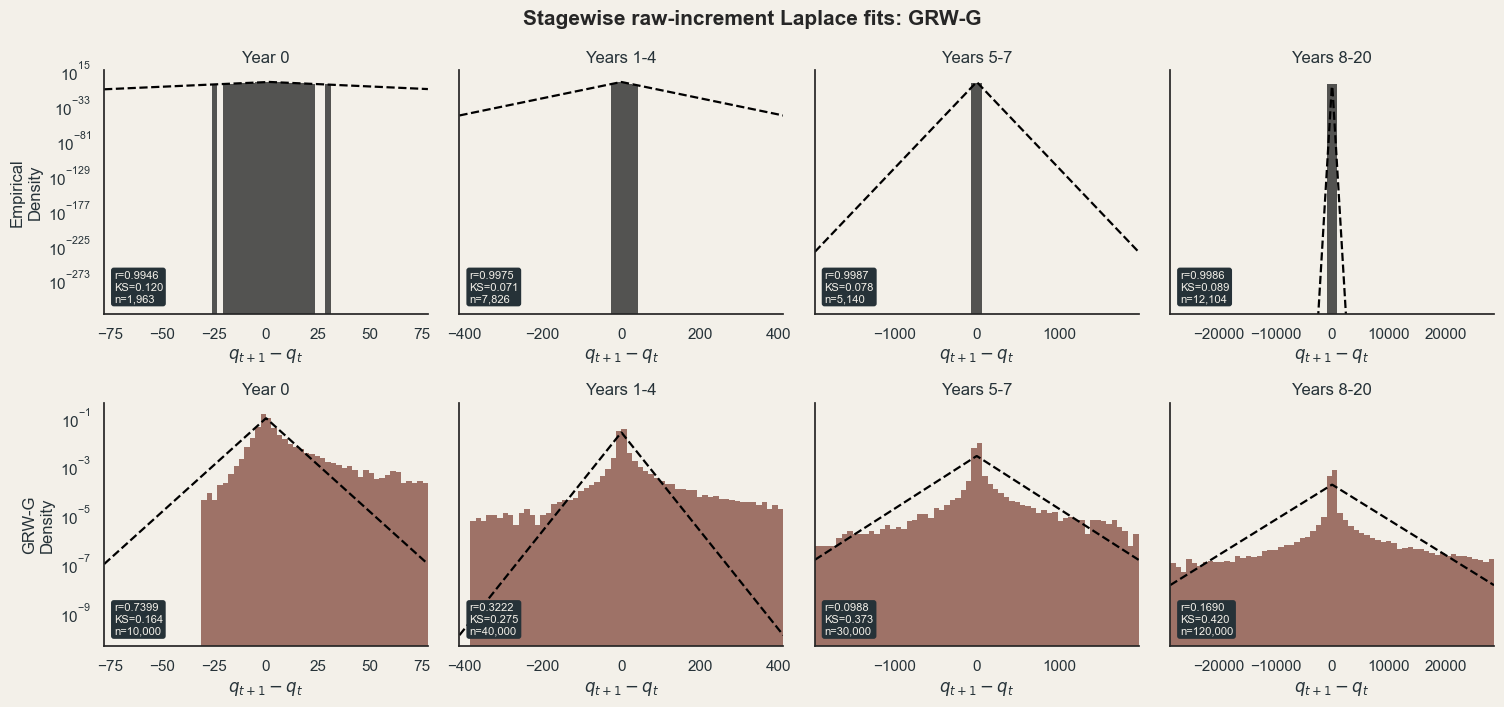

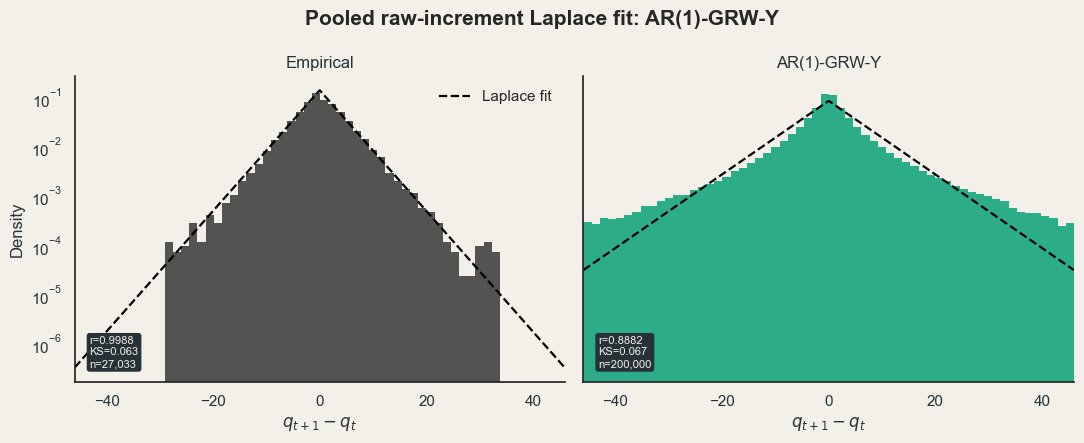

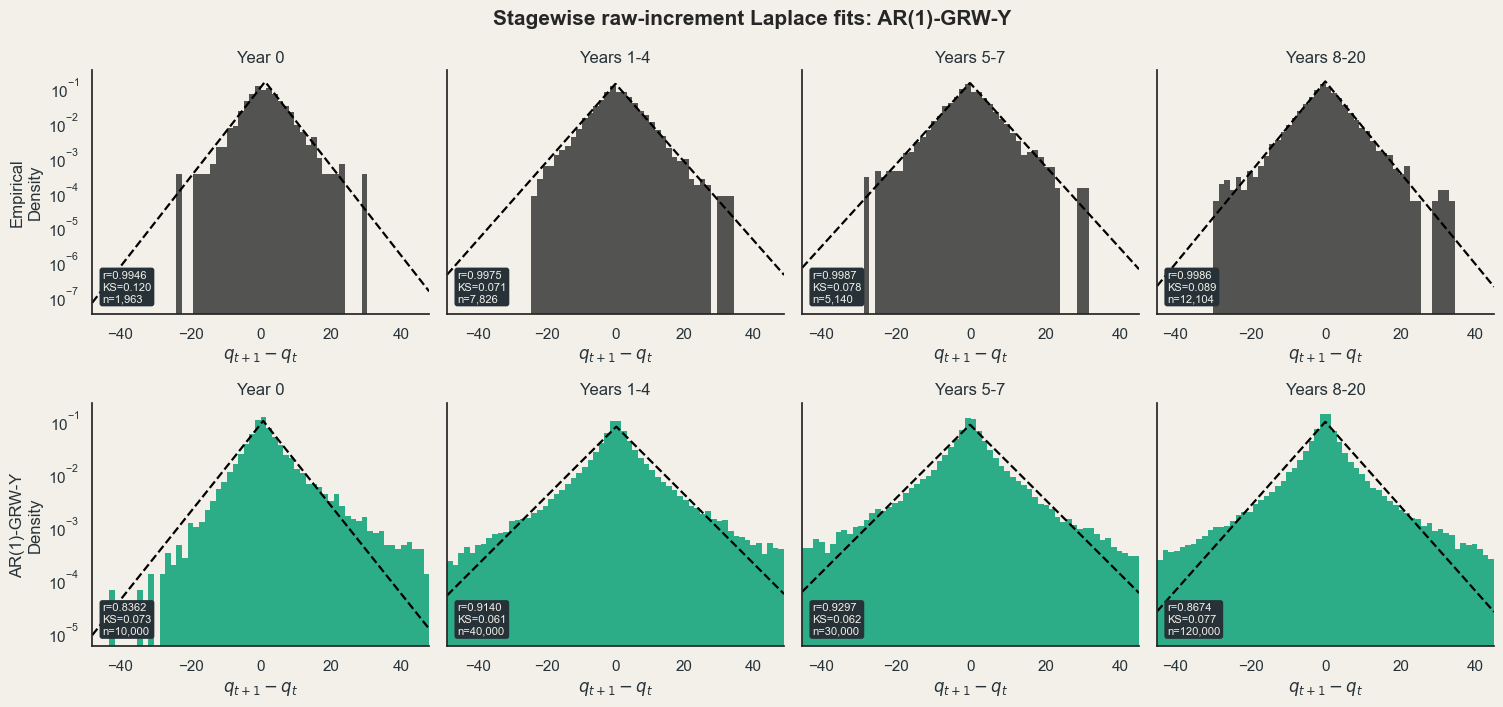

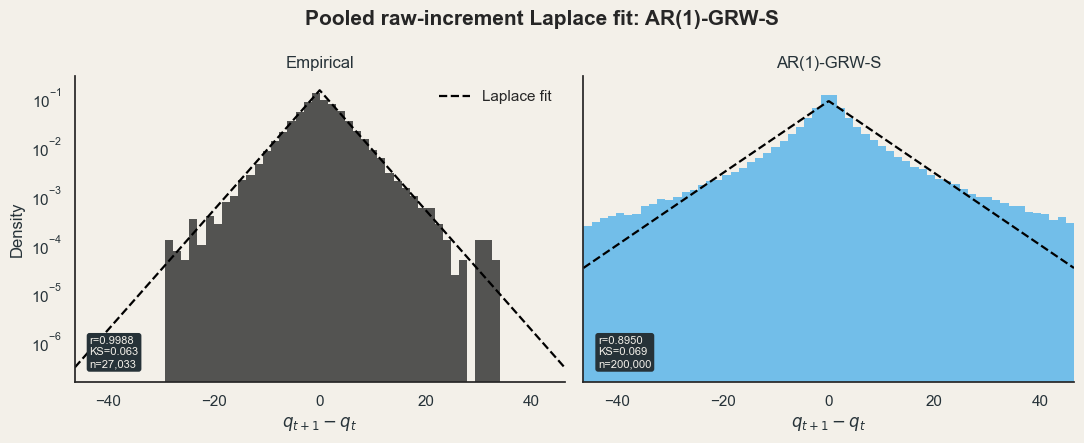

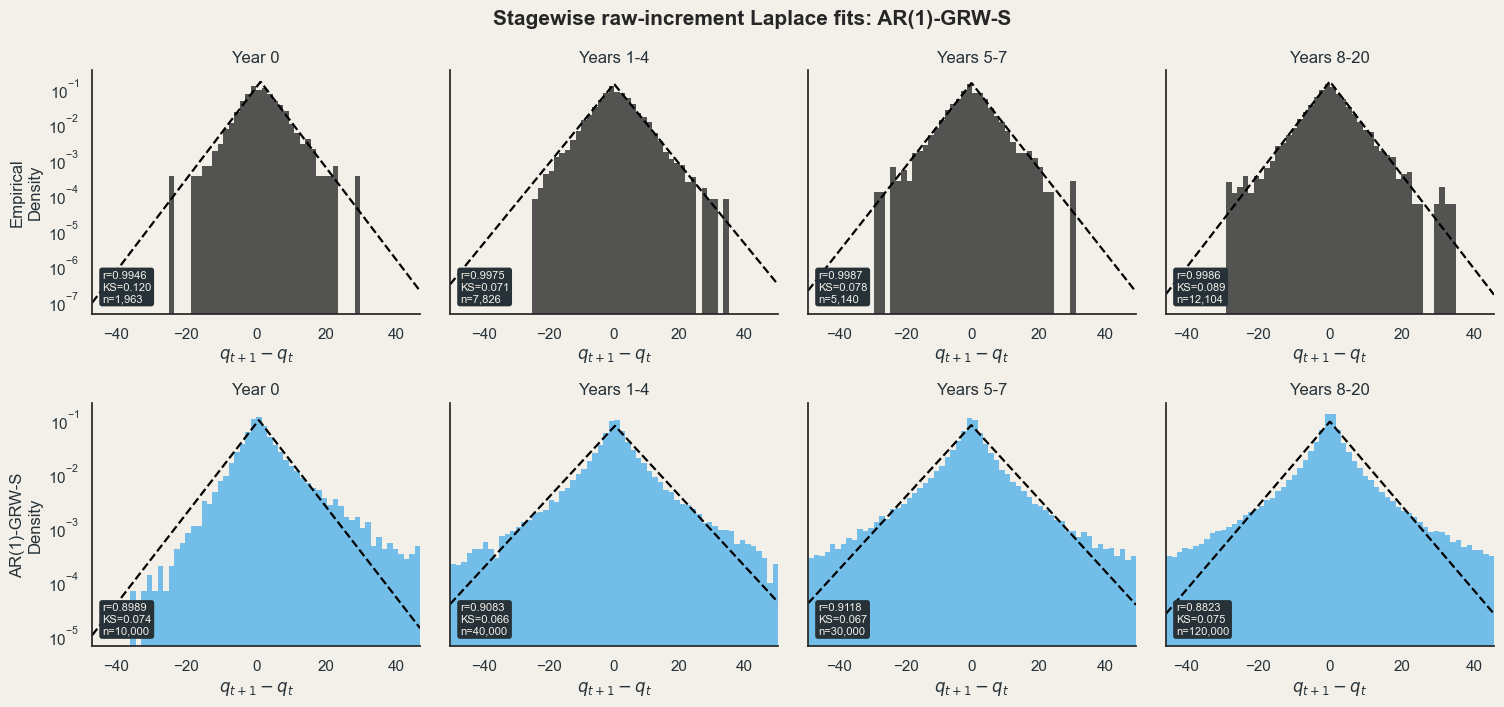

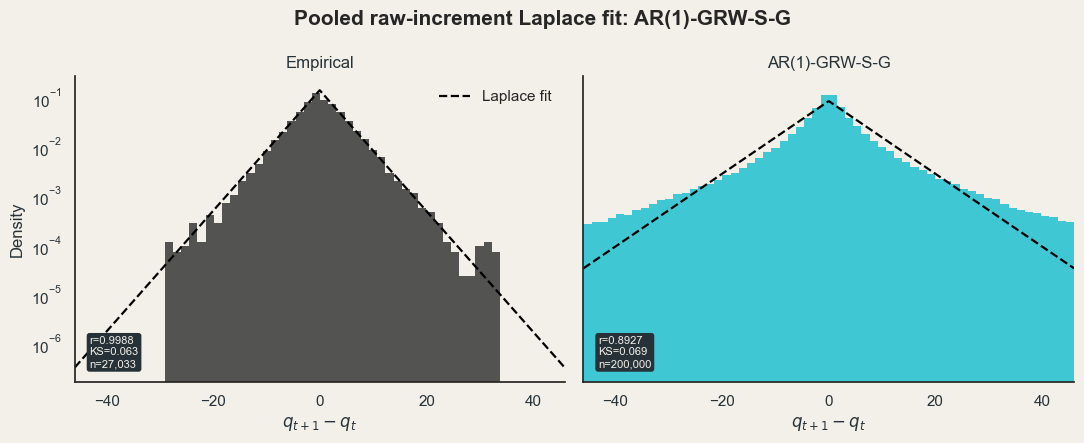

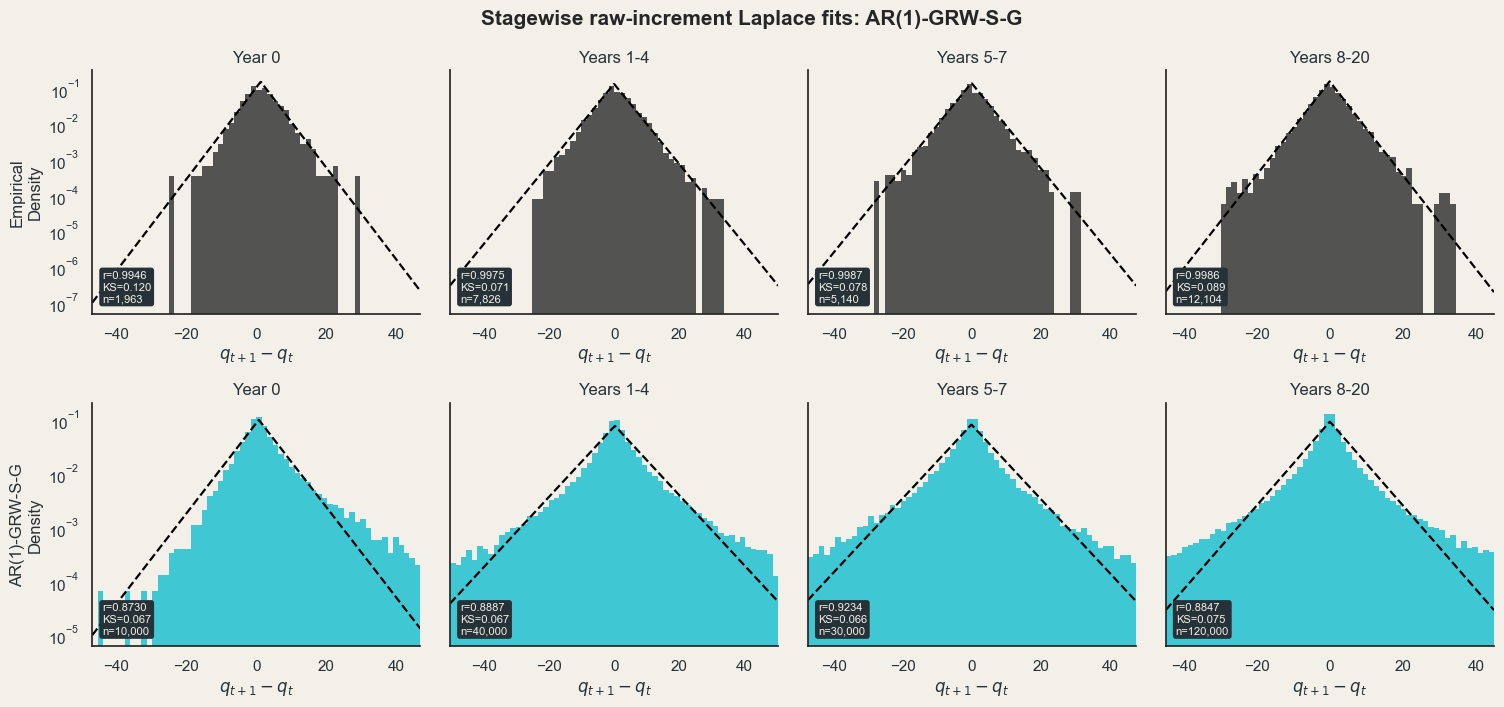

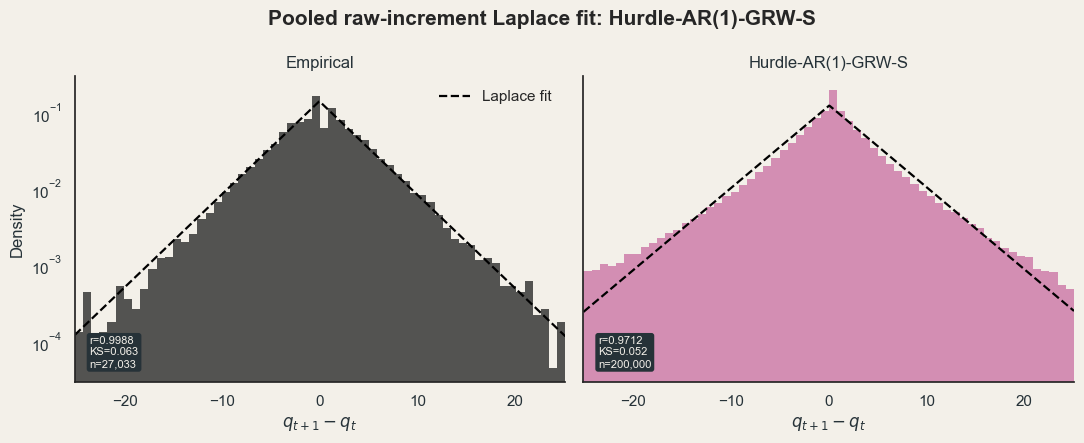

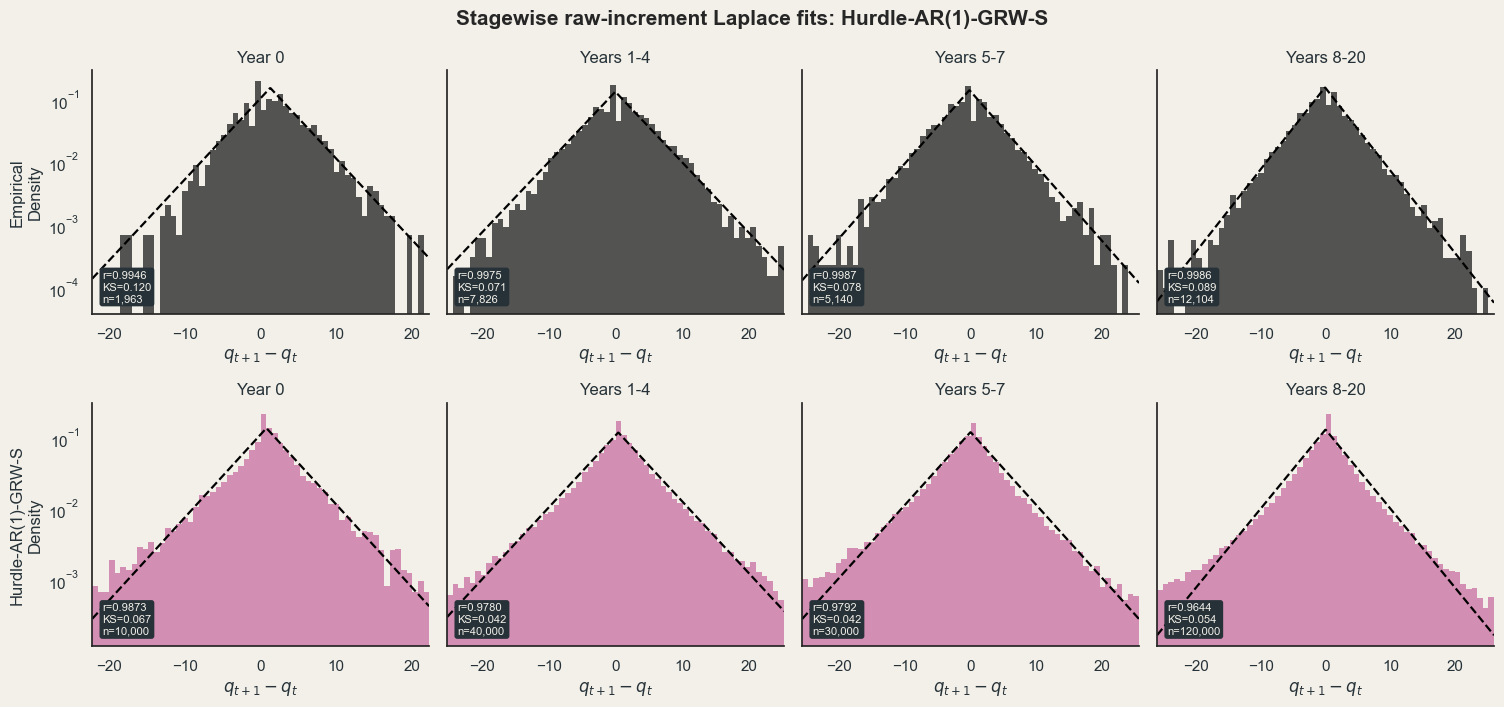

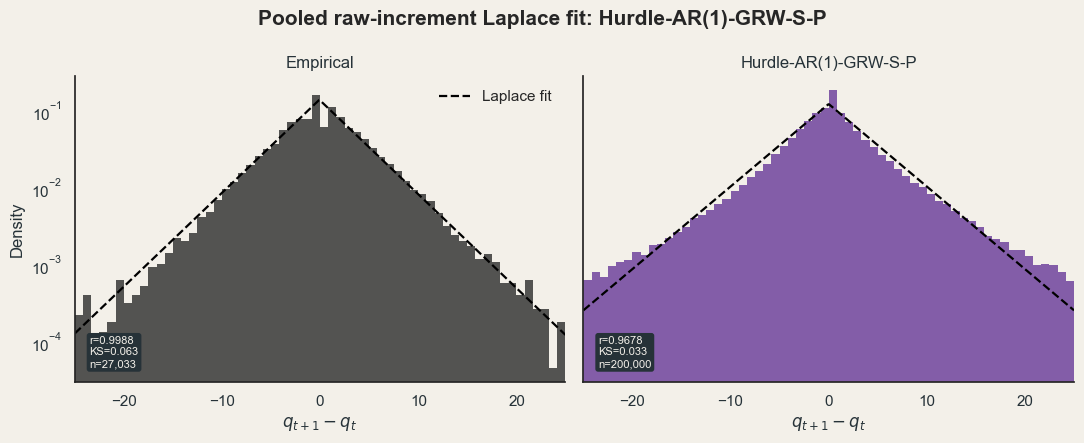

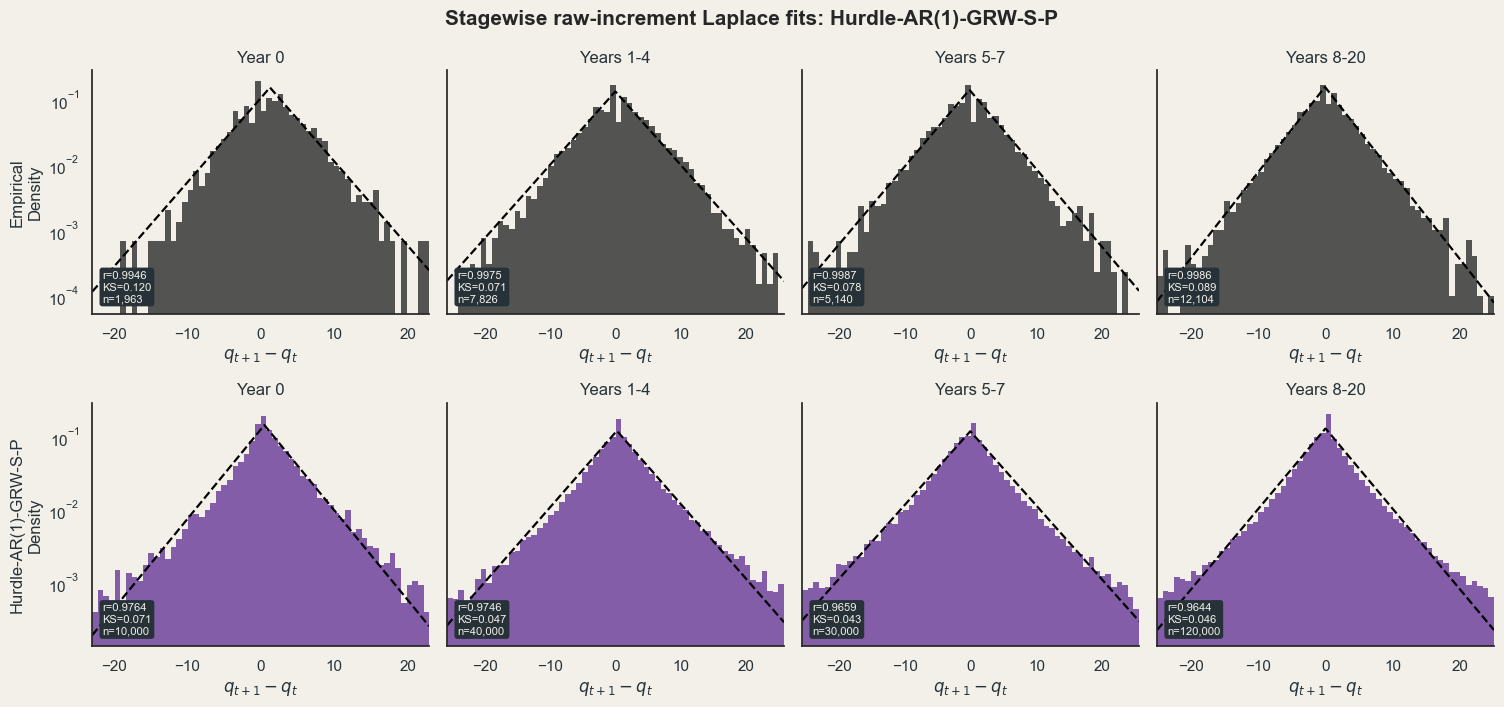

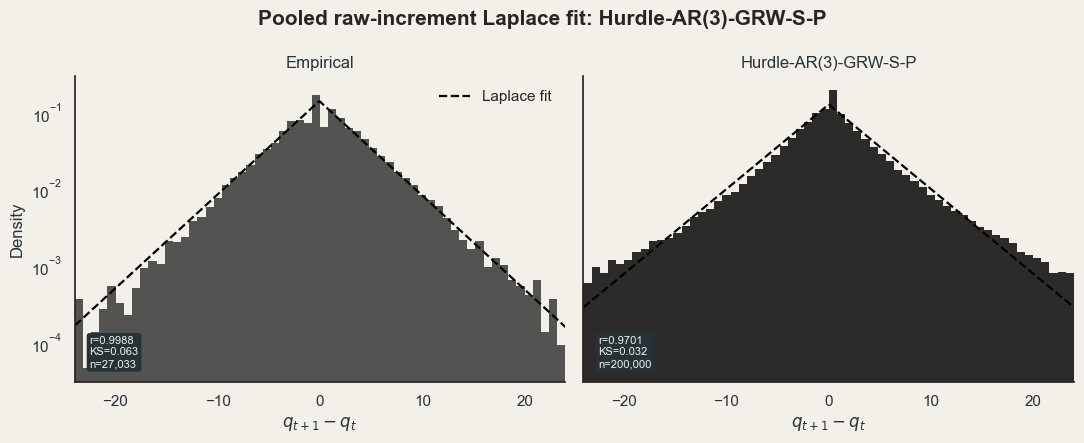

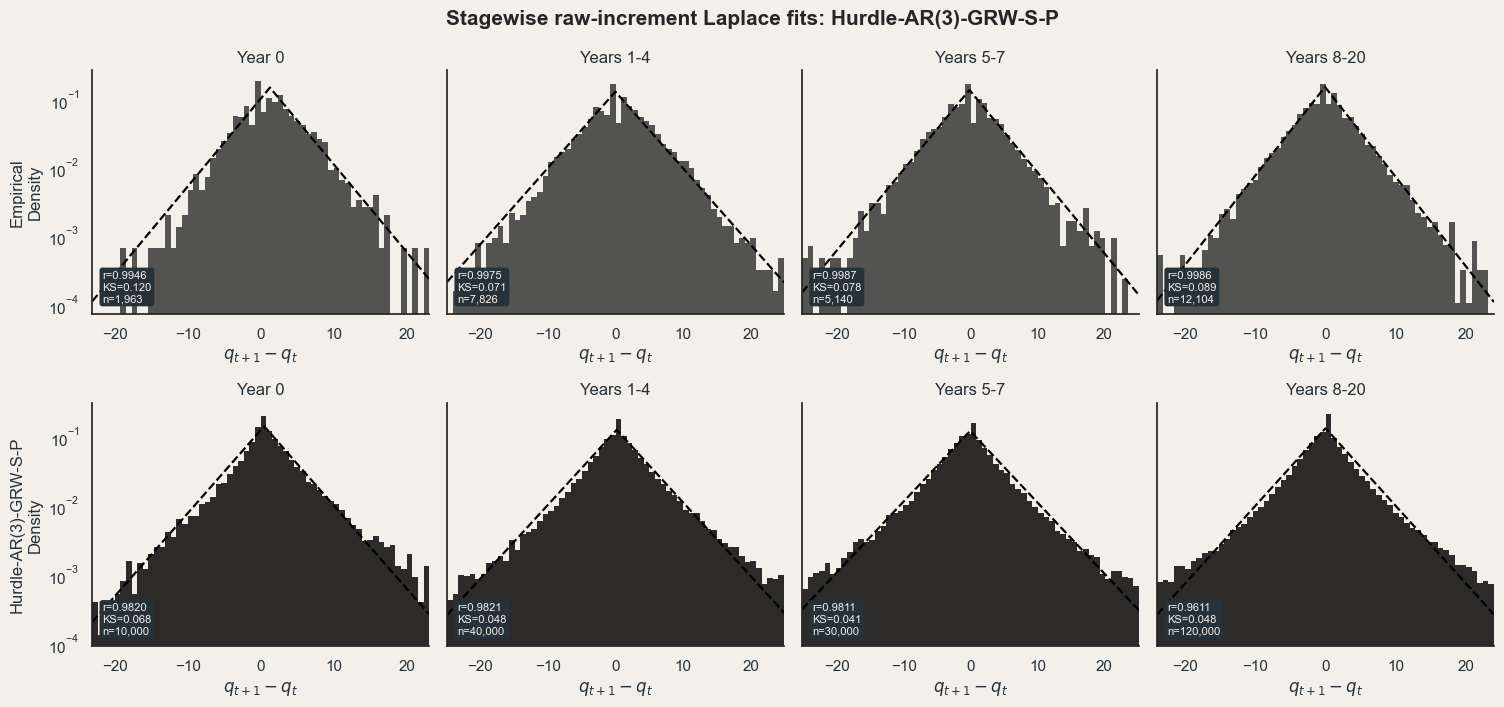

In [5]:
def symmetric_limits(*arrays):
    values = np.concatenate([clean_values(array) for array in arrays])
    lo, hi = np.quantile(values, [0.005, 0.995])
    limit = max(abs(lo), abs(hi), 1)
    return (-limit, limit)

def laplace_hist(ax, values, color, limits, title):
    values = clean_values(values)
    details = laplace_details(values)
    ax.hist(values, bins=60, range=limits, density=True, color=color, alpha=0.82, edgecolor="none")
    grid = np.linspace(*limits, 600)
    if np.isfinite(details["alpha"]) and details["alpha"] > 0:
        ax.plot(grid, stats.laplace.pdf(grid, loc=details["mu"], scale=details["alpha"]), color="black", lw=1.6, ls="--", label="Laplace fit")
    ax.set_yscale("log")
    ax.set_xlim(*limits)
    ax.set_title(title)
    ax.set_xlabel(r"$q_{t+1}-q_t$")
    ax.text(0.03, 0.05, f"r={details['corr']:.4f}\nKS={details['ks']:.3f}\nn={details['n']:,}", transform=ax.transAxes, fontsize=8, color=PAPER_BG, bbox={"facecolor": INK, "edgecolor": "none", "boxstyle": "round,pad=0.25"})
    style_axis(ax)

for tag in available_models:
    emp_pool, sim_pool = empirical_delta(0, 19), simulated_delta(trajs[tag], 0, 19)
    limits = symmetric_limits(emp_pool, sim_pool)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
    fig.patch.set_facecolor(PAPER_BG)
    laplace_hist(axes[0], emp_pool, EMP_COLOR, limits, "Empirical")
    laplace_hist(axes[1], sim_pool, MODEL_COLORS[tag], limits, MODEL_NAMES[tag])
    axes[0].set_ylabel("Density")
    axes[0].legend(frameon=False)
    fig.suptitle(f"Pooled raw-increment Laplace fit: {MODEL_NAMES[tag]}", fontsize=15, fontweight="bold")
    fig.tight_layout()
    savefig(fig, f"laplace_pooled_{tag}.png")
    plt.show()

    fig, axes = plt.subplots(2, 4, figsize=(15.2, 7.2), sharey="row")
    fig.patch.set_facecolor(PAPER_BG)
    for col, (window, start, end) in enumerate(LAPLACE_WINDOWS[1:]):
        emp_vals, sim_vals = empirical_delta(start, end), simulated_delta(trajs[tag], start, end)
        limits = symmetric_limits(emp_vals, sim_vals)
        laplace_hist(axes[0, col], emp_vals, EMP_COLOR, limits, window)
        laplace_hist(axes[1, col], sim_vals, MODEL_COLORS[tag], limits, window)
    axes[0, 0].set_ylabel("Empirical\nDensity")
    axes[1, 0].set_ylabel(f"{MODEL_NAMES[tag]}\nDensity")
    fig.suptitle(f"Stagewise raw-increment Laplace fits: {MODEL_NAMES[tag]}", fontsize=15, fontweight="bold")
    fig.tight_layout()
    savefig(fig, f"laplace_stagewise_{tag}.png")
    plt.show()